<a href="https://colab.research.google.com/github/anjanaem005-arch/_intermediate_assessment2_anjanaem/blob/main/assessment2_anjanaem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.model_selection import GridSearchCV

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
train_df = pd.read_csv('/content/drive/MyDrive/DATASCIENCE AND ANALYTICS/ASSESSMENT/train_LZdllcl.csv')

test_df = pd.read_csv('/content/drive/MyDrive/DATASCIENCE AND ANALYTICS/ASSESSMENT/test_2umaH9m.csv')

In [9]:
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [7]:
train_df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [8]:
train_df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [9]:
train_df.duplicated().sum()

np.int64(0)

In [10]:
numeric_columns = train_df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numeric_columns)

Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')


In [11]:
categorical_columns = train_df.select_dtypes(
    include=["object"]
).columns

print(categorical_columns)

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')


In [12]:
for col in categorical_columns:
    print("\n", col)
    print(train_df[col].unique())


 department
['Sales & Marketing' 'Operations' 'Technology' 'Analytics' 'R&D'
 'Procurement' 'Finance' 'HR' 'Legal']

 region
['region_7' 'region_22' 'region_19' 'region_23' 'region_26' 'region_2'
 'region_20' 'region_34' 'region_1' 'region_4' 'region_29' 'region_31'
 'region_15' 'region_14' 'region_11' 'region_5' 'region_28' 'region_17'
 'region_13' 'region_16' 'region_25' 'region_10' 'region_27' 'region_30'
 'region_12' 'region_21' 'region_8' 'region_32' 'region_6' 'region_33'
 'region_24' 'region_3' 'region_9' 'region_18']

 education
["Master's & above" "Bachelor's" nan 'Below Secondary']

 gender
['f' 'm']

 recruitment_channel
['sourcing' 'other' 'referred']


In [13]:
train_df["is_promoted"].value_counts()

,count
is_promoted,
0,50140
1,4668


In [14]:
train_df["education"].fillna(
    train_df["education"].mode()[0],
    inplace=True
)

/tmp/ipykernel_1596/2978740115.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["education"].fillna(


In [15]:
train_df["education"].value_counts()

,count
education,
Bachelor's,39078
Master's & above,14925
Below Secondary,805


In [16]:
train_df["previous_year_rating"].fillna(
    train_df["previous_year_rating"].median(),
    inplace=True
)

/tmp/ipykernel_1596/3625862356.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["previous_year_rating"].fillna(


In [17]:
train_df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [18]:
train_df.drop(columns = 'employee_id', inplace = True)

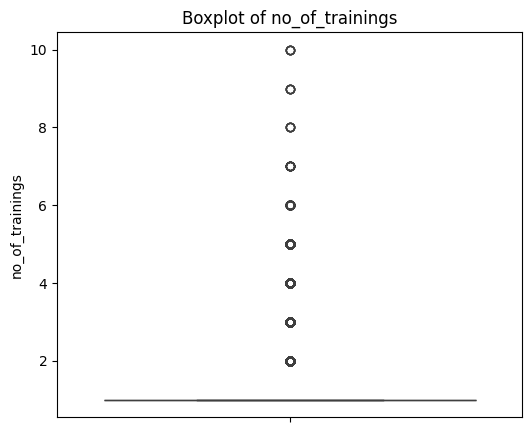

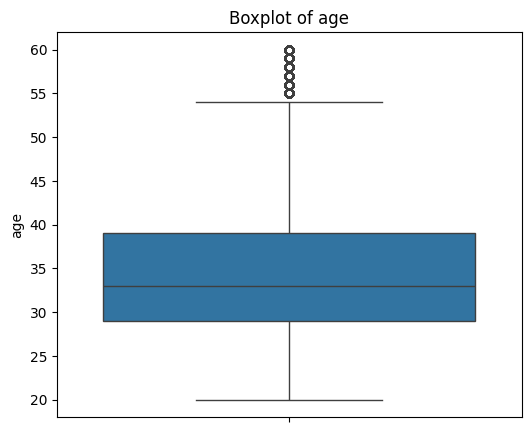

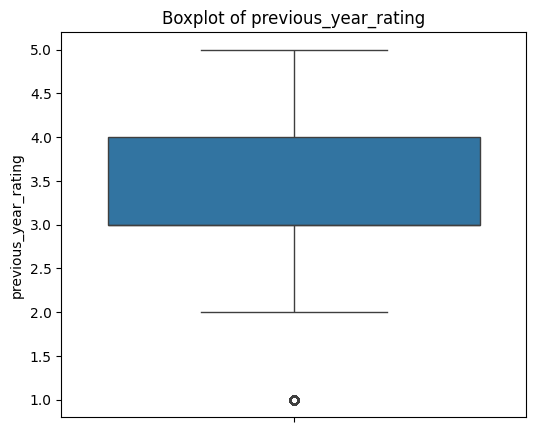

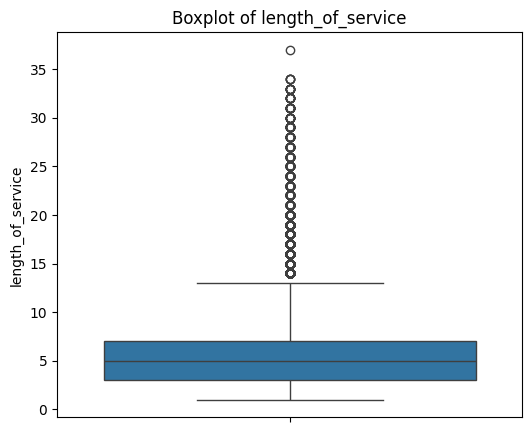

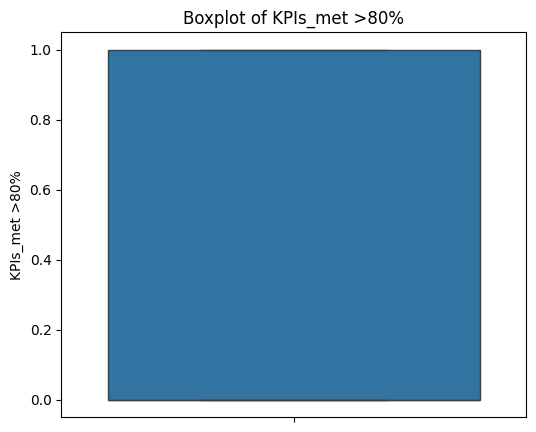

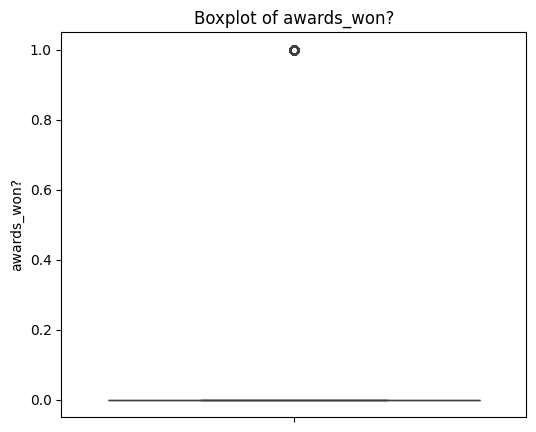

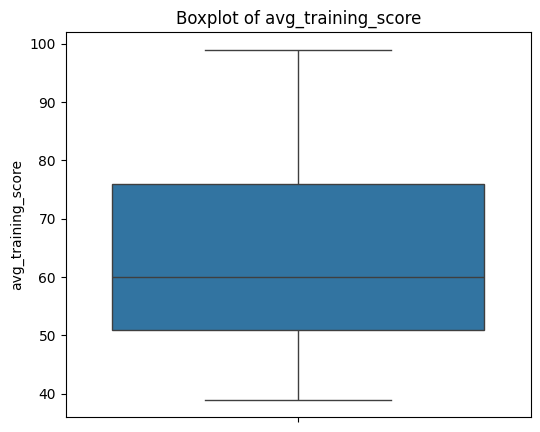

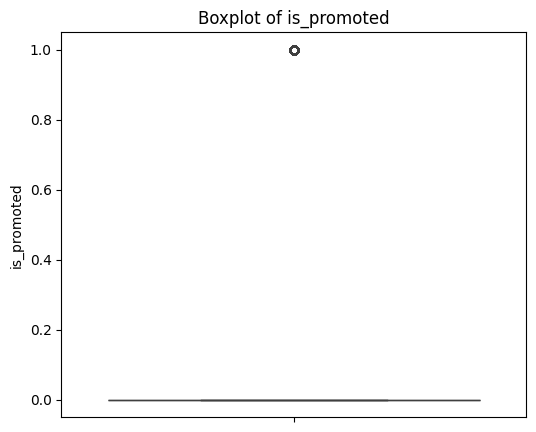

In [19]:
numerical_columns = train_df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numerical_columns:
    plt.figure(figsize=(6, 5))

    sns.boxplot(y=train_df[col])

    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

    plt.show()

In [20]:
categorical_columns = train_df.select_dtypes(
    include=["object"]
).columns

print(categorical_columns)

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')


In [21]:
train_df["gender"] = train_df["gender"].map({
    "m": 1,
    "f": 0
})

In [22]:
train_df["education"] = train_df["education"].map({
    "Below Secondary": 0,
    "Bachelor's": 1,
    "Master's & above": 2
})

In [23]:
train_df["recruitment_channel"] = train_df["recruitment_channel"].map({
    "sourcing": 0,
    "other": 1,
    "referred": 2
})

In [24]:
train_df["department"] = train_df["department"].map({
    "Finance": 0,
    "Sales & Marketing": 1,
    "Operations": 2,
    "Technology": 3,
    "Analytics": 4,
    "R&D": 5,
    "HR": 6,
    "Procurement": 7,
    "Legal": 8
})

In [25]:
train_df = pd.get_dummies(
    train_df,
    columns=["region"],
    drop_first=True,
    dtype=int
)

In [26]:
train_df.head()

,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,...,region_region_31,region_region_32,region_region_33,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9
0,1,2,0,0,1,35,5.0,8,1,0,...,0,0,0,0,0,0,0,1,0,0
1,2,1,1,1,1,30,5.0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,1,34,3.0,7,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,2,39,1.0,10,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,1,1,1,1,45,3.0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
X = train_df.drop("is_promoted", axis=1)
y = train_df["is_promoted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (43846, 44)
X_test: (10962, 44)
y_train: (43846,)
y_test: (10962,)


In [29]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Original:
is_promoted
0    0.91483
1    0.08517
Name: proportion, dtype: float64

Training:
is_promoted
0    0.914838
1    0.085162
Name: proportion, dtype: float64

Testing:
is_promoted
0    0.914797
1    0.085203
Name: proportion, dtype: float64


In [30]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train,
    y_train
)

#Oversampling


In [31]:
print("Before sampling:")
print(y_train.value_counts())

print("\nAfter sampling:")
print(y_train_resampled.value_counts())

Before sampling:
is_promoted
0    40112
1     3734
Name: count, dtype: int64

After sampling:
is_promoted
0    40112
1    40112
Name: count, dtype: int64


In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)

X_test_scaled = scaler.transform(X_test)

In [33]:
print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (80224, 44)
Scaled testing data: (10962, 44)


In [34]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

In [35]:
print("Original features:", X_train_scaled.shape[1])
print("PCA components:", X_train_pca.shape[1])

Original features: 44
PCA components: 40


In [36]:
print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: [0.04876405 0.03637622 0.03084767 0.02790169 0.02709708 0.02560005
 0.02472165 0.02441755 0.02417825 0.02386905 0.02373669 0.02364103
 0.02342663 0.02339082 0.02334006 0.02328942 0.02324757 0.02323644
 0.0231637  0.02312458 0.02308009 0.02304156 0.02303596 0.02301558
 0.02296552 0.02295328 0.02294595 0.02291531 0.02289207 0.0228825
 0.02282674 0.02277157 0.02244013 0.02227175 0.02177401 0.0211149
 0.02042179 0.02021523 0.01861458 0.01639609]
Total explained variance: 0.9659448188298831


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_over = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [38]:
rf_over.fit(
    X_train_pca,
    y_train_resampled
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [40]:
y_pred_over = rf_over.predict(
    X_test_pca
)

In [41]:
from sklearn.metrics import accuracy_score

accuracy_over = accuracy_score(
    y_test,
    y_pred_over
)

print("Oversampling + PCA Accuracy:", accuracy_over)

Oversampling + PCA Accuracy: 0.9017515051997811


In [42]:
from sklearn.metrics import f1_score

f1_over = f1_score(
    y_test,
    y_pred_over
)

print("Oversampling + PCA + Random Forest F1 Score:", f1_over)

Oversampling + PCA + Random Forest F1 Score: 0.24842986741102582


In [48]:
print("Classification Report:")

print(classification_report(y_test, y_pred_over))

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred_over))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10028
           1       0.36      0.19      0.25       934

    accuracy                           0.90     10962
   macro avg       0.64      0.58      0.60     10962
weighted avg       0.88      0.90      0.89     10962

Confusion Matrix:
[[9707  321]
 [ 756  178]]


In [50]:
print([name for name in globals() if name.startswith("y_pred")])

['y_pred_over']


In [52]:
print("Oversampled Model F1:", f1_score(y_test, y_pred_over))
print("Oversampled Model F1:", f1_score(y_test, y_pred_over))
print("Oversampled Model F1:", f1_score(y_test, y_pred_over))

Oversampled Model F1: 0.24842986741102582
Oversampled Model F1: 0.24842986741102582
Oversampled Model F1: 0.24842986741102582


In [53]:
print([name for name in globals() if any(
    word in name.lower()
    for word in ['model', 'pred', 'prob', 'threshold', 'score']
)])

['accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'y_pred_over']


In [63]:
print(rf_over.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [64]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1:", grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation F1: 0.9816205210779337


In [65]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("Promoted Class F1-Score:",
      f1_score(y_test, y_pred_tuned))

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     10028
           1       0.62      0.32      0.43       934

    accuracy                           0.93     10962
   macro avg       0.78      0.65      0.69     10962
weighted avg       0.91      0.93      0.91     10962

Confusion Matrix:
[[9843  185]
 [ 631  303]]
Promoted Class F1-Score: 0.42616033755274263


In [66]:
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_temp = (y_prob_tuned >= threshold).astype(int)
    print(
        f"Threshold: {threshold:.2f} | "
        f"F1-score: {f1_score(y_test, y_pred_temp):.4f}"
    )

Threshold: 0.20 | F1-score: 0.3957
Threshold: 0.25 | F1-score: 0.4164
Threshold: 0.30 | F1-score: 0.4367
Threshold: 0.35 | F1-score: 0.4492
Threshold: 0.40 | F1-score: 0.4527
Threshold: 0.45 | F1-score: 0.4399
Threshold: 0.50 | F1-score: 0.4216


In [67]:
best_threshold = 0.40

y_pred_final = (y_prob_tuned >= best_threshold).astype(int)

print("Final Validation F1-Score:",
      f1_score(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Validation F1-Score: 0.45272206303724927

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     10028
           1       0.49      0.42      0.45       934

    accuracy                           0.91     10962
   macro avg       0.72      0.69      0.70     10962
weighted avg       0.91      0.91      0.91     10962


Confusion Matrix:
[[9612  416]
 [ 539  395]]


In [68]:
print("Test Dataset Shape:", test_df.shape)

print("\nTest Dataset Columns:")
print(test_df.columns.tolist())

print("\nMissing Values:")
print(test_df.isnull().sum())

Test Dataset Shape: (23490, 13)

Test Dataset Columns:
['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']

Missing Values:
employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


In [69]:
print("Training feature columns:")
print(X_train.columns.tolist())

print("\nTraining feature shape:", X_train.shape)

print("\nBest model:")
print(best_rf)

Training feature columns:
['department', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'region_region_10', 'region_region_11', 'region_region_12', 'region_region_13', 'region_region_14', 'region_region_15', 'region_region_16', 'region_region_17', 'region_region_18', 'region_region_19', 'region_region_2', 'region_region_20', 'region_region_21', 'region_region_22', 'region_region_23', 'region_region_24', 'region_region_25', 'region_region_26', 'region_region_27', 'region_region_28', 'region_region_29', 'region_region_3', 'region_region_30', 'region_region_31', 'region_region_32', 'region_region_33', 'region_region_34', 'region_region_4', 'region_region_5', 'region_region_6', 'region_region_7', 'region_region_8', 'region_region_9']

Training feature shape: (43846, 44)

Best model:
RandomForestClassifier(n_jobs=-1, random_state=42)


In [70]:
test_processed = test_df.copy()

test_processed['education'] = test_processed['education'].fillna(
    test_processed['education'].mode()[0]
)

test_processed['previous_year_rating'] = test_processed['previous_year_rating'].fillna(
    test_processed['previous_year_rating'].mode()[0]
)

test_processed = pd.get_dummies(
    test_processed,
    columns=['region'],
    prefix='region',
    dtype=int
)

print("Processed test shape:", test_processed.shape)
print("Remaining missing values:", test_processed.isnull().sum().sum())

Processed test shape: (23490, 46)
Remaining missing values: 0


In [71]:
test_features = test_processed.drop(columns=['employee_id'])

test_features = test_features.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Aligned test shape:", test_features.shape)
print("Training shape:", X_train.shape)
print("Columns match:", list(test_features.columns) == list(X_train.columns))

Aligned test shape: (23490, 44)
Training shape: (43846, 44)
Columns match: True


In [82]:
department_map = {
    'Sales & Marketing': 0,
    'Operations': 1,
    'Technology': 2,
    'Procurement': 3,
    'Analytics': 4,
    'Finance': 5,
    'HR': 6,
    'Legal': 7,
    'R&D': 8
}

education_map = {
    'Below Secondary': 0,
    "Bachelor's": 1,
    "Master's & above": 2
}

gender_map = {
    'f': 0,
    'm': 1
}

recruitment_map = {
    'other': 0,
    'sourcing': 1,
    'referred': 2
}

test_features['department'] = test_df['department'].map(department_map)
test_features['education'] = test_df['education'].map(education_map)
test_features['gender'] = test_df['gender'].map(gender_map)
test_features['recruitment_channel'] = test_df['recruitment_channel'].map(recruitment_map)

print(test_features[cat_cols].head())
print("\nMissing values:")
print(test_features[cat_cols].isnull().sum())

   department  education  gender  recruitment_channel
0           2        1.0       1                    1
1           6        1.0       0                    0
2           0        1.0       1                    0
3           3        1.0       0                    0
4           5        1.0       1                    1

Missing values:
department                0
education              1034
gender                    0
recruitment_channel       0
dtype: int64


In [83]:
test_features['education'] = test_features['education'].fillna(
    train_df['education'].mode()[0]
)

print("Missing values:", test_features.isnull().sum().sum())
print("Shape:", test_features.shape)
print(test_features.head())

Missing values: 0
Shape: (23490, 44)
   department  education  gender  recruitment_channel  no_of_trainings  age  \
0           2        1.0       1                    1                1   24   
1           6        1.0       0                    0                1   31   
2           0        1.0       1                    0                1   31   
3           3        1.0       0                    0                3   31   
4           5        1.0       1                    1                1   30   

   previous_year_rating  length_of_service  KPIs_met >80%  awards_won?  ...  \
0                   3.0                  1              1            0  ...   
1                   3.0                  5              0            0  ...   
2                   1.0                  4              0            0  ...   
3                   2.0                  9              0            0  ...   
4                   4.0                  7              0            0  ...   

   region_reg

In [85]:
test_probabilities = best_rf.predict_proba(test_features)[:, 1]

print("Prediction probabilities generated:", len(test_probabilities))
print(test_probabilities[:10])

Prediction probabilities generated: 23490
[0.53 0.04 0.   0.   0.07 0.05 0.17 0.02 0.46 0.61]


In [86]:
test_predictions = (test_probabilities >= 0.4).astype(int)

print("Prediction counts:")
print(pd.Series(test_predictions).value_counts())

Prediction counts:
0    18380
1     5110
Name: count, dtype: int64


In [88]:
submission_check = pd.read_csv('/content/drive/MyDrive/DATASCIENCE AND ANALYTICS/ASSESSMENT/sample_submission_M0L0uXE.csv')

print(submission_check.head())
print(submission_check.shape)
print(submission_check.isnull().sum())

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)
employee_id    0
is_promoted    0
dtype: int64


In [89]:
submission_check['is_promoted'] = test_predictions

submission_check.head()

,employee_id,is_promoted
0,8724,1
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [90]:
print(submission_check.columns.tolist())
print(submission_check.head())

['employee_id', 'is_promoted']
   employee_id  is_promoted
0         8724            1
1        74430            0
2        72255            0
3        38562            0
4        64486            0


In [93]:
submission_check.to_csv('submission.csv', index=False)

print("CSV saved successfully!")

CSV saved successfully!


In [94]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [95]:
!pip install xgboost

In [96]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [97]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [98]:
xgb_predictions = xgb_model.predict(X_test)

print("F1 Score:", f1_score(y_test, xgb_predictions))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_predictions))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, xgb_predictions))

F1 Score: 0.37156775907883083

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.73      0.84     10028
           1       0.23      0.90      0.37       934

    accuracy                           0.74     10962
   macro avg       0.61      0.81      0.60     10962
weighted avg       0.92      0.74      0.80     10962


Confusion Matrix:

[[7285 2743]
 [  95  839]]


In [99]:
import numpy as np
from sklearn.metrics import f1_score

xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.61, 0.01)

xgb_f1_scores = [
    f1_score(y_test, (xgb_probabilities >= threshold).astype(int))
    for threshold in thresholds
]

best_xgb_threshold = thresholds[np.argmax(xgb_f1_scores)]
best_xgb_f1 = max(xgb_f1_scores)

print("Best Threshold:", best_xgb_threshold)
print("Best XGBoost F1 Score:", best_xgb_f1)

Best Threshold: 0.5999999999999998
Best XGBoost F1 Score: 0.41798642533936653


In [100]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_resampled, y_train_resampled)

gb_probabilities = gb_model.predict_proba(X_test)[:, 1]

In [101]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.81, 0.01)

gb_f1_scores = [
    f1_score(y_test, (gb_probabilities >= threshold).astype(int))
    for threshold in thresholds
]

best_gb_threshold = thresholds[np.argmax(gb_f1_scores)]
best_gb_f1 = max(gb_f1_scores)

print("Best Threshold:", best_gb_threshold)
print("Best Gradient Boosting F1 Score:", best_gb_f1)

Best Threshold: 0.7099999999999996
Best Gradient Boosting F1 Score: 0.48546824542518835


In [102]:
gb_test_probabilities = gb_model.predict_proba(test_features)[:, 1]

gb_test_predictions = (
    gb_test_probabilities >= best_gb_threshold
).astype(int)

print(pd.Series(gb_test_predictions).value_counts())

0    16971
1     6519
Name: count, dtype: int64


In [103]:
gb_submission = submission_check.copy()

gb_submission['is_promoted'] = gb_test_predictions

gb_submission.to_csv('submission_gradient_boosting.csv', index=False)

from google.colab import files
files.download('submission_gradient_boosting.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [104]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train_resampled, y_train_resampled)

ada_probabilities = ada_model.predict_proba(X_test)[:, 1]

In [105]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.81, 0.01)

ada_f1_scores = [
    f1_score(y_test, (ada_probabilities >= threshold).astype(int))
    for threshold in thresholds
]

best_ada_threshold = thresholds[np.argmax(ada_f1_scores)]
best_ada_f1 = max(ada_f1_scores)

print("Best Threshold:", best_ada_threshold)
print("Best AdaBoost F1 Score:", best_ada_f1)

Best Threshold: 0.34999999999999987
Best AdaBoost F1 Score: 0.3044053696350917


In [107]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
AdaBoostClassifier           ABCMeta                       <class 'sklearn.ensemble.<...>ting.AdaBoostClassifier'>
ColumnTransformer            ABCMeta                       <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
GridSearchCV                 ABCMeta                       <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder                type                          <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
OrdinalEncoder               type                        

In [115]:
print("Training missing values:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nTest missing values:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Training missing values:
Series([], dtype: int64)

Test missing values:
education               1034
previous_year_rating    1812
dtype: int64


In [116]:
print("Education mode:", train_df['education'].mode()[0])
print("Previous year rating mode:", train_df['previous_year_rating'].mode()[0])

print("\nTest missing values after preprocessing:")
print(test_features.isnull().sum().sum())

Education mode: 1
Previous year rating mode: 3.0

Test missing values after preprocessing:
0


In [117]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in X_train_resampled:", X_train_resampled.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in X_train_resampled: 0


In [118]:
print(train_df['is_promoted'].value_counts())

print("\nPercentage distribution:")
print(train_df['is_promoted'].value_counts(normalize=True) * 100)

is_promoted
0    50140
1     4668
Name: count, dtype: int64

Percentage distribution:
is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64


In [119]:
print(y_train_resampled.value_counts())

is_promoted
0    40112
1    40112
Name: count, dtype: int64


In [120]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
AdaBoostClassifier           ABCMeta                       <class 'sklearn.ensemble.<...>ting.AdaBoostClassifier'>
ColumnTransformer            ABCMeta                       <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
GridSearchCV                 ABCMeta                       <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder                type                          <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
OrdinalEncoder               type                        

In [122]:
print("y_test:", len(y_test))
print("Random Forest:", len(y_prob_tuned))
print("Gradient Boosting:", len(gb_probabilities))
print("XGBoost:", len(xgb_probabilities))
print("AdaBoost:", len(ada_probabilities))

y_test: 10962
Random Forest: 10962
Gradient Boosting: 10962
XGBoost: 10962
AdaBoost: 10962


In [123]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Random Forest": (y_prob_tuned, best_threshold),
    "Gradient Boosting": (gb_probabilities, best_gb_threshold),
    "XGBoost": (xgb_probabilities, best_xgb_threshold),
    "AdaBoost": (ada_probabilities, best_ada_threshold)
}

for name, (probabilities, threshold) in models.items():
    predictions = (probabilities >= threshold).astype(int)

    print(f"\n{name}")
    print("Threshold:", round(threshold, 2))
    print("Precision:", round(precision_score(y_test, predictions), 4))
    print("Recall:", round(recall_score(y_test, predictions), 4))
    print("F1 Score:", round(f1_score(y_test, predictions), 4))


Random Forest
Threshold: 0.4
Precision: 0.4871
Recall: 0.4229
F1 Score: 0.4527

Gradient Boosting
Threshold: 0.71
Precision: 0.4881
Recall: 0.4829
F1 Score: 0.4855

XGBoost
Threshold: 0.6
Precision: 0.284
Recall: 0.7912
F1 Score: 0.418

AdaBoost
Threshold: 0.35
Precision: 0.1848
Recall: 0.8619
F1 Score: 0.3044


In [124]:
print(gb_model.get_params())

{'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [128]:
param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_leaf': [3]
}

In [129]:
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [130]:
gb_grid_search.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [2, 3],
                         'min_samples_leaf': [3], 'n_estimators': [100, 150]},
             scoring='f1', verbose=1)

In [131]:
print("Best Parameters:", gb_grid_search.best_params_)
print("Best Cross-Validation F1 Score:", gb_grid_search.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 150}
Best Cross-Validation F1 Score: 0.8434569462620941


In [132]:
best_gb_model = gb_grid_search.best_estimator_

gb_tuned_probabilities = best_gb_model.predict_proba(X_test)[:, 1]

gb_tuned_predictions = (gb_tuned_probabilities >= 0.5).astype(int)

print(classification_report(y_test, gb_tuned_predictions))

              precision    recall  f1-score   support

           0       0.99      0.71      0.83     10028
           1       0.23      0.91      0.36       934

    accuracy                           0.73     10962
   macro avg       0.61      0.81      0.60     10962
weighted avg       0.92      0.73      0.79     10962



In [133]:
from sklearn.metrics import f1_score
import numpy as np

thresholds_gb = np.arange(0.30, 0.81, 0.01)

f1_scores_gb = []

for t in thresholds_gb:
    predictions = (gb_tuned_probabilities >= t).astype(int)
    f1_scores_gb.append(f1_score(y_test, predictions))

best_index_gb = np.argmax(f1_scores_gb)

print("Best Threshold:", thresholds_gb[best_index_gb])
print("Best Validation F1:", f1_scores_gb[best_index_gb])

Best Threshold: 0.7400000000000004
Best Validation F1: 0.5037128712871287


In [134]:
best_gb_threshold = thresholds_gb[best_index_gb]

gb_tuned_final_predictions = (
    gb_tuned_probabilities >= best_gb_threshold
).astype(int)

print(classification_report(y_test, gb_tuned_final_predictions))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     10028
           1       0.60      0.44      0.50       934

    accuracy                           0.93     10962
   macro avg       0.77      0.70      0.73     10962
weighted avg       0.92      0.93      0.92     10962



In [135]:
gb_tuned_test_probabilities = best_gb_model.predict_proba(test_features)[:, 1]

gb_tuned_test_predictions = (
    gb_tuned_test_probabilities >= best_gb_threshold
).astype(int)

print(pd.Series(gb_tuned_test_predictions).value_counts())

0    16636
1     6854
Name: count, dtype: int64


In [136]:
gb_tuned_submission = submission_check.copy()

gb_tuned_submission['is_promoted'] = gb_tuned_test_predictions

gb_tuned_submission.to_csv(
    'submission_gradient_boosting_tuned.csv',
    index=False
)

print(gb_tuned_submission.head())
print("\nShape:", gb_tuned_submission.shape)

   employee_id  is_promoted
0         8724            1
1        74430            0
2        72255            0
3        38562            0
4        64486            0

Shape: (23490, 2)


In [137]:
print("Shape:", gb_tuned_submission.shape)

print("\nMissing values:")
print(gb_tuned_submission.isnull().sum())

print("\nTarget distribution:")
print(gb_tuned_submission['is_promoted'].value_counts())

print("\nDuplicate employee IDs:")
print(gb_tuned_submission['employee_id'].duplicated().sum())

Shape: (23490, 2)

Missing values:
employee_id    0
is_promoted    0
dtype: int64

Target distribution:
is_promoted
0    16636
1     6854
Name: count, dtype: int64

Duplicate employee IDs:
0


In [138]:
from google.colab import files

files.download('submission_gradient_boosting_tuned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [4]:
import catboost
print(catboost.__version__)

1.2.10


In [5]:
print("XGBoost:", 'xgb_model' in globals())
print("Gradient Boosting:", 'best_gb_model' in globals())
print("CatBoost:", 'cat_model' in globals())

XGBoost: False
Gradient Boosting: False
CatBoost: False


In [62]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_pca, y_train_resampled)

print("XGBoost training completed!")

XGBoost training completed!


In [63]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train_pca, y_train_resampled)

print("CatBoost training completed!")

CatBoost training completed!


In [64]:
xgb_val_prob = xgb_model.predict_proba(X_test_pca)[:, 1]

cat_val_prob = cat_model.predict_proba(X_test_pca)[:, 1]

rf_val_prob = rf_over.predict_proba(X_test_pca)[:, 1]

print("XGBoost probabilities generated:", len(xgb_val_prob))
print("CatBoost probabilities generated:", len(cat_val_prob))
print("Random Forest probabilities generated:", len(rf_val_prob))

XGBoost probabilities generated: 10962
CatBoost probabilities generated: 10962
Random Forest probabilities generated: 10962


In [65]:
from sklearn.metrics import f1_score
import numpy as np

ensemble_val_prob = (
    0.33 * xgb_val_prob +
    0.33 * cat_val_prob +
    0.34 * rf_val_prob
)

thresholds = np.arange(0.10, 0.81, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred_ensemble = (ensemble_val_prob >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_ensemble))

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Ensemble Threshold:", round(best_threshold, 2))
print("Best Ensemble F1 Score:", round(best_f1, 4))

Best Ensemble Threshold: 0.54
Best Ensemble F1 Score: 0.3481


In [66]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_ensemble = (ensemble_val_prob >= best_threshold).astype(int)

print("Ensemble Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ensemble))

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     10028
           1       0.29      0.43      0.35       934

    accuracy                           0.86     10962
   macro avg       0.62      0.67      0.64     10962
weighted avg       0.89      0.86      0.87     10962

Confusion Matrix:
[[9059  969]
 [ 533  401]]


In [73]:
department_map = {
    'Sales & Marketing': 0, 'Operations': 1, 'Technology': 2,
    'Procurement': 3, 'Analytics': 4, 'Finance': 5,
    'HR': 6, 'Legal': 7, 'R&D': 8
}

education_map = {
    'Below Secondary': 0, "Bachelor's": 1, "Master's & above": 2
}

gender_map = {'f': 0, 'm': 1}

recruitment_map = {
    'other': 0, 'sourcing': 1, 'referred': 2
}

test_features = test_df.copy()

test_features['education'] = test_features['education'].fillna(1)
test_features['previous_year_rating'] = test_features['previous_year_rating'].fillna(3.0)

test_features['department'] = test_features['department'].map(department_map)
test_features['education'] = test_features['education'].map(education_map)
test_features['gender'] = test_features['gender'].map(gender_map)
test_features['recruitment_channel'] = test_features['recruitment_channel'].map(recruitment_map)

test_features = test_features.drop(columns=['employee_id'])

print("Shape:", test_features.shape)
print("Missing values:", test_features.isnull().sum().sum())

Shape: (23490, 12)
Missing values: 1034


In [74]:
test_features['education'] = test_features['education'].fillna(1)

print("Missing values:", test_features.isnull().sum().sum())

Missing values: 0


In [76]:
test_features = pd.get_dummies(
    test_features,
    columns=['region'],
    prefix='region'
)

test_features = test_features.reindex(
    columns=scaler.feature_names_in_,
    fill_value=0
)

test_scaled = scaler.transform(test_features)
test_pca = pca.transform(test_scaled)

print("Test PCA shape:", test_pca.shape)

Test PCA shape: (23490, 40)


In [77]:
xgb_test_prob = xgb_model.predict_proba(test_pca)[:, 1]
cat_test_prob = cat_model.predict_proba(test_pca)[:, 1]
rf_test_prob = rf_over.predict_proba(test_pca)[:, 1]

ensemble_test_prob = (
    0.33 * xgb_test_prob +
    0.33 * cat_test_prob +
    0.34 * rf_test_prob
)

ensemble_test_pred = (
    ensemble_test_prob >= best_threshold
).astype(int)

print("Predictions:", len(ensemble_test_pred))
print("Promoted:", sum(ensemble_test_pred))
print("Not promoted:", len(ensemble_test_pred) - sum(ensemble_test_pred))

Predictions: 23490
Promoted: 2833
Not promoted: 20657


In [79]:
submission_ensemble = pd.DataFrame({
    'employee_id': test_df['employee_id'],
    'is_promoted': ensemble_test_pred
})

submission_ensemble.to_csv(
    '/content/submission_ensemble_xgb_cat_rf.csv',
    index=False
)

print("Shape:", submission_ensemble.shape)
print("Missing values:", submission_ensemble.isnull().sum().sum())
print(submission_ensemble.head())

Shape: (23490, 2)
Missing values: 0
   employee_id  is_promoted
0         8724            1
1        74430            0
2        72255            0
3        38562            0
4        64486            0


In [80]:
from sklearn.metrics import f1_score
import numpy as np

ensemble_xgb_cat = (
    0.5 * xgb_val_prob +
    0.5 * cat_val_prob
)

thresholds = np.arange(0.10, 0.81, 0.01)

scores = [
    f1_score(y_test, (ensemble_xgb_cat >= t).astype(int))
    for t in thresholds
]

best_idx = np.argmax(scores)

best_threshold_xgb_cat = thresholds[best_idx]

print("Best threshold:", best_threshold_xgb_cat)
print("Validation F1:", scores[best_idx])

Best threshold: 0.6399999999999997
Validation F1: 0.3507779349363508


In [81]:
ensemble_xgb_cat_test = (
    0.5 * xgb_test_prob +
    0.5 * cat_test_prob
)

ensemble_xgb_cat_pred = (
    ensemble_xgb_cat_test >= best_threshold_xgb_cat
).astype(int)

submission_xgb_cat = pd.DataFrame({
    'employee_id': test_df['employee_id'],
    'is_promoted': ensemble_xgb_cat_pred
})

submission_xgb_cat.to_csv(
    '/content/submission_xgb_cat.csv',
    index=False
)

print(submission_xgb_cat.shape)
print(submission_xgb_cat['is_promoted'].value_counts())

(23490, 2)
is_promoted
0    19559
1     3931
Name: count, dtype: int64


In [82]:
from google.colab import files

files.download('/content/submission_xgb_cat.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
import numpy as np
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0

for threshold in np.arange(0.40, 0.81, 0.01):

    val_prob = 0.7 * xgb_val_prob + 0.3 * cat_val_prob

    val_pred = (val_prob >= threshold).astype(int)

    score = f1_score(y_test, val_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best F1 Score:", best_f1)
print("Best Threshold:", best_threshold)

Best F1 Score: 0.3523238380809595
Best Threshold: 0.6500000000000002


In [84]:
test_prob = 0.7 * xgb_test_prob + 0.3 * cat_test_prob

test_pred = (test_prob >= 0.65).astype(int)

submission = pd.DataFrame({
    'employee_id': test_df['employee_id'],
    'is_promoted': test_pred
})

submission.to_csv('/content/submission_xgb70_cat30.csv', index=False)

print(submission['is_promoted'].value_counts())
print("Submission saved successfully!")

is_promoted
0    19858
1     3632
Name: count, dtype: int64
Submission saved successfully!


In [85]:
from google.colab import files
files.download('/content/submission_xgb70_cat30.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>